In [15]:
# ==========================================================================
# STARTER CODE
# ==========================================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats
import warnings

warnings.filterwarnings("ignore")


housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()
print(f"Dataset shape: {df.shape}")
print(f"Target: MedHouseVal (median house value in $100k)")
print(df.head())

X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")


Dataset shape: (20640, 9)
Target: MedHouseVal (median house value in $100k)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Training set: 16512 samples
Test set:     4128 samples


               MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc       1.000000 -0.119034  0.326895  -0.062040    0.004834  0.018766   
HouseAge    -0.119034  1.000000 -0.153277  -0.077747   -0.296244  0.013191   
AveRooms     0.326895 -0.153277  1.000000   0.847621   -0.072213 -0.004852   
AveBedrms   -0.062040 -0.077747  0.847621   1.000000   -0.066197 -0.006181   
Population   0.004834 -0.296244 -0.072213  -0.066197    1.000000  0.069863   
AveOccup     0.018766  0.013191 -0.004852  -0.006181    0.069863  1.000000   
Latitude    -0.079809  0.011173  0.106389   0.069721   -0.108785  0.002366   
Longitude   -0.015176 -0.108197 -0.027540   0.013344    0.099773  0.002476   
MedHouseVal  0.688075  0.105623  0.151948  -0.046701   -0.024650 -0.023737   

             Latitude  Longitude  MedHouseVal  
MedInc      -0.079809  -0.015176     0.688075  
HouseAge     0.011173  -0.108197     0.105623  
AveRooms     0.106389  -0.027540     0.151948  
AveBedrms    0.069721   0.0

<Axes: >

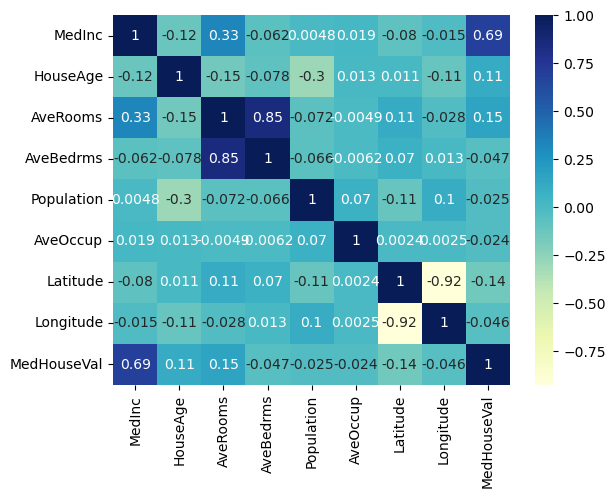

In [16]:
#1a: Create a correlation matrix 
co_mtx = df.corr()
print(co_mtx)

sns.heatmap(data=co_mtx, cmap="YlGnBu", annot=True)

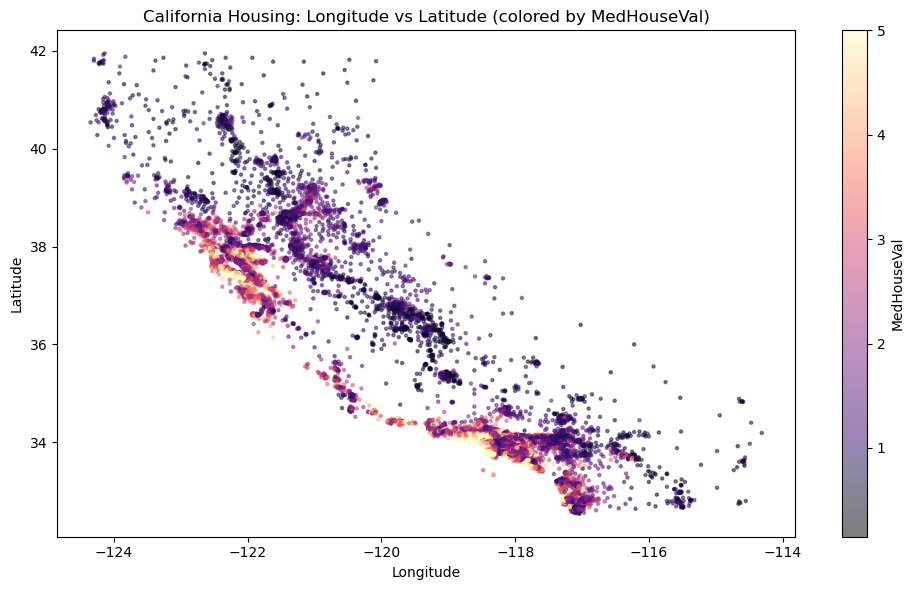

In [17]:
#1b Scatter plot of Longitude vs Latitude colored by MedHouseVal
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df["Longitude"], df["Latitude"],
    c=df["MedHouseVal"], cmap="magma",
    s=5, alpha=0.5
)
plt.colorbar(scatter, label="MedHouseVal")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("California Housing: Longitude vs Latitude (colored by MedHouseVal)")
plt.tight_layout()
plt.show()

#Longitude values are negative in California as its in the western hemeisphere.

In [18]:
#1c. Descriptive Statistics for Train and test sets
train_stats = X_train.describe().T
test_stats = X_test.describe().T

print("Training Set Descriptive Statistics")
print(train_stats)
print("Test Set Descriptive Statistics ")
print(test_stats)

Training Set Descriptive Statistics
              count         mean          std         min         25%  \
MedInc      16512.0     3.880754     1.904294    0.499900    2.566700   
HouseAge    16512.0    28.608285    12.602499    1.000000   18.000000   
AveRooms    16512.0     5.435235     2.387375    0.888889    4.452055   
AveBedrms   16512.0     1.096685     0.433215    0.333333    1.006508   
Population  16512.0  1426.453004  1137.056380    3.000000  789.000000   
AveOccup    16512.0     3.096961    11.578744    0.692308    2.428799   
Latitude    16512.0    35.643149     2.136665   32.550000   33.930000   
Longitude   16512.0  -119.582290     2.005654 -124.350000 -121.810000   

                    50%          75%           max  
MedInc         3.545800     4.773175     15.000100  
HouseAge      29.000000    37.000000     52.000000  
AveRooms       5.235874     6.061037    141.909091  
AveBedrms      1.049286     1.100348     25.636364  
Population  1167.000000  1726.000000  356

In [19]:
#2 Data Preperation
#Looking for missing values in the training and test sets
print("Missing X_train values")
print(X_train.isnull().sum())
print("Missing X_test values")
print(X_test.isnull().sum())



Missing X_train values
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64
Missing X_test values
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


In [20]:
#Look for outliers
for col in X_train:
    print(f"{col} upper tail")
    print(X_train[col].describe(percentiles=[0.01, 0.05, 0.95, 0.99]).to_string())

#Winsorize AveRooms, AveBedrms, AveOccup, Population as they have extreme outliers at 99th percentile

MedInc upper tail
count    16512.000000
mean         3.880754
std          1.904294
min          0.499900
1%           1.066898
5%           1.599460
50%          3.545800
95%          7.310800
99%         10.576902
max         15.000100
HouseAge upper tail
count    16512.000000
mean        28.608285
std         12.602499
min          1.000000
1%           4.000000
5%           8.000000
50%         29.000000
95%         52.000000
99%         52.000000
max         52.000000
AveRooms upper tail
count    16512.000000
mean         5.435235
std          2.387375
min          0.888889
1%           2.578195
5%           3.438549
50%          5.235874
95%          7.645946
99%         10.318432
max        141.909091
AveBedrms upper tail
count    16512.000000
mean         1.096685
std          0.433215
min          0.333333
1%           0.871161
5%           0.939394
50%          1.049286
95%          1.276685
99%          2.116536
max         25.636364
Population upper tail
count    16512.0000

In [21]:
for col in X_test:
    print(f"{col} upper tail")
    print(X_test[col].describe(percentiles=[0.01, 0.05, 0.95, 0.99]).to_string())

#Winsorise same variables at 99th percentile 

MedInc upper tail
count    4128.000000
mean        3.830338
std         1.881515
min         0.499900
1%          1.076377
5%          1.603300
50%         3.500000
95%         7.251275
99%        10.795759
max        15.000100
HouseAge upper tail
count    4128.000000
mean       28.764293
std        12.518304
min         1.000000
1%          4.000000
5%          8.000000
50%        29.000000
95%        52.000000
99%        52.000000
max        52.000000
AveRooms upper tail
count    4128.000000
mean        5.404059
std         2.794717
min         0.846154
1%          2.628426
5%          3.421648
50%         5.192764
95%         7.628639
99%        10.469400
max       132.533333
AveBedrms upper tail
count    4128.000000
mean        1.096637
std         0.610196
min         0.500000
1%          0.876786
5%          0.936887
50%         1.046715
95%         1.261315
99%         2.127606
max        34.066667
Population upper tail
count     4128.000000
mean      1421.571705
std       1114.

In [22]:
winsorize_cols = ["AveRooms", "AveBedrms", "AveOccup", "Population"]

therehold_99 = X_train[winsorize_cols].quantile(0.99)

for col in winsorize_cols:
    upper_limit = therehold_99[col]
    X_train[col] = X_train[col].clip(upper=upper_limit)
    X_test[col] = X_test[col].clip(upper=upper_limit)

for col in winsorize_cols:
    print(f"\n=== {col} upper tail ===")
    print(X_train[col].describe(percentiles=[0.01, 0.05, 0.95, 0.99]).to_string())




=== AveRooms upper tail ===
count    16512.000000
mean         5.338885
std          1.328725
min          0.888889
1%           2.578195
5%           3.438549
50%          5.235874
95%          7.645946
99%         10.315997
max         10.318432

=== AveBedrms upper tail ===
count    16512.000000
mean         1.076879
std          0.159676
min          0.333333
1%           0.871161
5%           0.939394
50%          1.049286
95%          1.276685
99%          2.115940
max          2.116536

=== AveOccup upper tail ===
count    16512.000000
mean         2.913836
std          0.735558
min          0.692308
1%           1.538838
5%           1.872511
50%          2.817240
95%          4.333333
99%          5.408202
max          5.410157

=== Population upper tail ===
count    16512.000000
mean      1404.685594
std        972.781719
min          3.000000
1%          88.110000
5%         349.000000
50%       1167.000000
95%       3282.450000
99%       5794.020800
max       5798.720000


In [23]:
for col in winsorize_cols:
    print(f"\n=== {col} upper tail ===")
    print(X_test[col].describe(percentiles=[0.01, 0.05, 0.95, 0.99]).to_string())


=== AveRooms upper tail ===
count    4128.000000
mean        5.295449
std         1.327532
min         0.846154
1%          2.628426
5%          3.421648
50%         5.192764
95%         7.628639
99%        10.318432
max        10.318432

=== AveBedrms upper tail ===
count    4128.000000
mean        1.073364
std         0.157937
min         0.500000
1%          0.876786
5%          0.936887
50%         1.046715
95%         1.261315
99%         2.116536
max         2.116536

=== AveOccup upper tail ===
count    4128.000000
mean        2.921254
std         0.734162
min         1.263566
1%          1.524794
5%          1.874175
50%         2.823586
95%         4.336877
99%         5.375092
max         5.410157

=== Population upper tail ===
count    4128.000000
mean     1398.968014
std       974.735361
min         8.000000
1%         86.540000
5%        341.350000
50%      1160.000000
95%      3325.650000
99%      5798.720000
max      5798.720000


In [24]:
#3a
# Compute skewness of every feature in X_train
skewness = X_train.skew()
print("Skewness of all features:")
print(skewness)
print()

#Find features where skeweness exceeds 1
high_skew_features = skewness[skewness.abs() > 1.0].index.tolist()


#Applying log1p to features in Train and test
for features in high_skew_features:
    X_train[features] = np.log1p(X_train[features])
    X_test[features] = np.log1p(X_test[features])



#Computer skewness of y
y_skew = y_train.skew()
print(f"Skewness of y_train: {y_skew:.4f}")


y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)
print(f"Skewness of y_train_log: {y_train_log.skew():.4f}")


Skewness of all features:
MedInc        1.634090
HouseAge      0.063453
AveRooms      0.742404
AveBedrms     3.949669
Population    1.949434
AveOccup      0.842771
Latitude      0.461504
Longitude    -0.288418
dtype: float64

Skewness of y_train: 0.9765
Skewness of y_train_log: 0.2772


In [25]:
#4a
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)


In [31]:
#4b

model = LinearRegression()
model.fit(X_train_scaled, y_train_log)

print("Model fitted successfully.")
print(f"Intercept: {model.intercept_:.4f}")
print(f"Coefficients:")
for name, coef in zip(X_train.columns, model.coef_):
    print(f"  {name}: {coef:.4f}")

Model fitted successfully.
Intercept: 1.0571
Coefficients:
  MedInc: 0.2435
  HouseAge: 0.0355
  AveRooms: -0.0405
  AveBedrms: 0.0480
  Population: 0.0086
  AveOccup: -0.0752
  Latitude: -0.3351
  Longitude: -0.3060
